# Fisheries Conflict Analysis
This code combines the following datasets:
- WWF fisheries conflict event dataset  
    - Data provicded by sponsor
- Sea Surface Temperature data
    - https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html
- Southern Osciallation Index data 
    - mhttps://www.climate.gov/news-features/understanding-climate/climate-variability-southern-oscillation-index

In [2]:
# Load packages 
import pandas as pd
import os
import requests
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

## Obtain WWF data

In [5]:
# WWF data
WWF_data = pd.read_excel('data/WWF_data.xlsx')

## Obtain Sea Surface Temperature data
- sst_diff_same_month_degC: the difference between the SST of that month and the historical same-calendar-month SST mean

In [15]:
# Only need to do once 
sst_dir = "data"
sst_file = os.path.join(sst_dir, "sst.mnmean.nc")

# A global monthly SST analysis from 1854-present derived from ICOADS data with missing data filled in by statistical methods
sst_download_url = (
    "https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc"
)

os.makedirs(sst_dir, exist_ok=True)

if not os.path.exists(sst_file):
    print("Downloading NOAA ERSST v5 SST file...")
    
    response = requests.get(sst_download_url, stream=True)
    response.raise_for_status()
    
    with open(sst_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    
    print("Download complete:", sst_file)
else:
    print("SST file already exists:", sst_file)

SST file already exists: data\sst.mnmean.nc


In [12]:
# open NOAA dataset
sst_dir = "data"
sst_file = os.path.join(sst_dir, "sst.mnmean.nc")
sst_ds = xr.open_dataset(sst_file, engine="netcdf4")

# inspect SST variable
sst_ds["sst"]

<xarray.DataArray 'sst' (time: 2070, lat: 89, lon: 180)> Size: 133MB
[33161400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-06-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

In [13]:
# Add NOAA ERSST monthly SST to WWF event data
def haversine_km(lat1, lon1, lat2, lon2):
    lon1 = ((lon1 + 180) % 360) - 180
    lon2 = ((lon2 + 180) % 360) - 180

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


def add_sst_to_events(
    events_df,
    sst_ds,
    date_col="date",
    lat_col="latitude",
    lon_col="longitude",
    max_radius_deg=10
):

    df_sst = events_df.copy()

    df_sst[date_col] = pd.to_datetime(df_sst[date_col], errors="coerce")

    df_sst["sst_time"] = (
        df_sst[date_col]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    df_sst["lon_360"] = df_sst[lon_col] % 360

    lookup = (
        df_sst[["sst_time", lat_col, "lon_360"]]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
    )

    sst_subset = sst_ds.sel(
        time=slice(
            lookup["sst_time"].min(),
            lookup["sst_time"].max()
        )
    )

    def lookup_sst(row):
        event_time = row["sst_time"]
        event_lat = row[lat_col]
        event_lon = row["lon_360"]

        sst_month = sst_subset["sst"].sel(
            time=event_time,
            method="nearest"
        )

        for radius in range(0, max_radius_deg + 1, 2):

            lat_min = event_lat - radius
            lat_max = event_lat + radius
            lon_min = event_lon - radius
            lon_max = event_lon + radius

            lat_slice = slice(lat_max, lat_min)

            if lon_min < 0:
                candidate = xr.concat(
                    [
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(lon_min % 360, 358)
                        ),
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(0, lon_max)
                        )
                    ],
                    dim="lon"
                )

            elif lon_max > 358:
                candidate = xr.concat(
                    [
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(lon_min, 358)
                        ),
                        sst_month.sel(
                            lat=lat_slice,
                            lon=slice(0, lon_max % 360)
                        )
                    ],
                    dim="lon"
                )

            else:
                candidate = sst_month.sel(
                    lat=lat_slice,
                    lon=slice(lon_min, lon_max)
                )

            valid = candidate.where(~np.isnan(candidate), drop=True)

            if valid.size > 0:
                valid_df = (
                    valid
                    .to_dataframe(name="sst_degC")
                    .reset_index()
                    .dropna(subset=["sst_degC"])
                )

                valid_df["sst_distance_km"] = valid_df.apply(
                    lambda x: haversine_km(
                        event_lat,
                        event_lon,
                        x["lat"],
                        x["lon"]
                    ),
                    axis=1
                )

                closest = valid_df.sort_values("sst_distance_km").iloc[0]

                return pd.Series({
                    "matched_sst_lat": closest["lat"],
                    "matched_sst_lon": closest["lon"],
                    "sst_degC": closest["sst_degC"],
                    "sst_search_radius_deg": radius,
                    "sst_distance_km": closest["sst_distance_km"]
                })

        return pd.Series({
            "matched_sst_lat": np.nan,
            "matched_sst_lon": np.nan,
            "sst_degC": np.nan,
            "sst_search_radius_deg": np.nan,
            "sst_distance_km": np.nan
        })

    sst_values = lookup.apply(lookup_sst, axis=1)

    lookup = pd.concat([lookup, sst_values], axis=1)

    df_sst = df_sst.merge(
        lookup,
        on=["sst_time", lat_col, "lon_360"],
        how="left"
    )

    return df_sst

In [14]:
# Adds historical same-calendar-month SST mean and difference.
    # For each event:
    # - Uses the matched NOAA ERSST grid cell.
    # - Uses only prior years for the same calendar month.
    # - Excludes the event month itself.

def add_sst_diff_same_month(
    events_df,
    sst_ds,
    date_col="date",
    matched_lat_col="matched_sst_lat",
    matched_lon_col="matched_sst_lon",
    sst_col="sst_degC"
):

    df_anom = events_df.copy()

    df_anom[date_col] = pd.to_datetime(df_anom[date_col], errors="coerce")

    df_anom["sst_time"] = (
        df_anom[date_col]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    df_anom["sst_month"] = df_anom["sst_time"].dt.month

    def historical_same_month_mean(row):
        if (
            pd.isna(row[matched_lat_col])
            or pd.isna(row[matched_lon_col])
            or pd.isna(row["sst_time"])
        ):
            return np.nan

        event_time = row["sst_time"]
        event_month = row["sst_month"]

        history = sst_ds["sst"].sel(
            lat=row[matched_lat_col],
            lon=row[matched_lon_col],
            method="nearest"
        )

        history = history.sel(
            time=history["time"] < event_time
        )

        history_same_month = history.sel(
            time=history["time"].dt.month == event_month
        )

        return float(history_same_month.mean().values)

    df_anom["sst_historical_same_month_mean_degC"] = df_anom.apply(
        historical_same_month_mean,
        axis=1
    )

    df_anom["sst_diff_same_month_degC"] = (
        df_anom[sst_col]
        - df_anom["sst_historical_same_month_mean_degC"]
    )

    return df_anom

In [15]:
# run the functions to add SST and find the SST difference from the month's historical average
df_with_sst_ocean = add_sst_to_events(
    events_df=WWF_data,
    sst_ds=sst_ds,
    date_col="date",
    lat_col="latitude",
    lon_col="longitude",
    max_radius_deg=10
)

df_with_sst_diff = add_sst_diff_same_month(
    events_df=df_with_sst_ocean,
    sst_ds=sst_ds,
    date_col="date"
)

In [16]:
# check - SST created variables
df_with_sst_diff[[
    "date",
    "sst_degC",
    "sst_historical_same_month_mean_degC",
    "sst_diff_same_month_degC"
]].head()

,date,sst_degC,sst_historical_same_month_mean_degC,sst_diff_same_month_degC
0,2011-12-01,28.764431,28.586988,0.177443
1,2011-10-12,26.528063,26.232477,0.295586
2,2011-08-01,29.538723,29.193617,0.345106
3,2011-11-10,29.095762,28.614426,0.481337
4,2011-10-13,28.260935,27.538280,0.722654


In [17]:
# check if there are any missing values
print("Count of records missing sst_degC: ", df_with_sst_diff["sst_degC"].isna().sum())
# df_with_sst_anom["sst_distance_km"].describe()


# Return rows with missing values
display(df_with_sst_diff[df_with_sst_diff["sst_degC"].isna()][
    ["date", "region", "country", "latitude", "longitude", "matched_sst_lat", "matched_sst_lon"]])

Count of records missing sst_degC:  3


,date,region,country,latitude,longitude,matched_sst_lat,matched_sst_lon
336,2011-04-11,Horn of Africa,Tanzania,-4.429992,29.791667,NaN,NaN
599,2014-11-15,Horn of Africa,Tanzania,-5.680850,29.708213,NaN,NaN
922,1995-09-01,Horn of Africa,Tanzania,-4.839290,29.670720,NaN,NaN


In [18]:
# drop WWF records with missing values
df_model = df_with_sst_diff.dropna(
    subset=["sst_diff_same_month_degC"]).copy()

# Confirm there are no missing values now
df_model["sst_degC"].isna().sum()

np.int64(0)

In [19]:
# check events where the matched ocean pixel is far away
df_model[df_model["sst_distance_km"] > 300]["country"].value_counts()

country
Kenya       172
Tanzania     77
Russia        2
Name: count, dtype: int64

In [20]:
# create new df with points less than 300 km away
df_model_close = df_model[df_model["sst_distance_km"] <= 300].copy()

## Obtain Southern Oscillation Index Data 

In [21]:
#Load dataset
soi_data = pd.read_csv('data/soi.txt', sep=r'\s+', header=0)

# make months a digit
soi_data = soi_data.melt(id_vars='YEAR', var_name = 'month', value_name='soi')
soi_data.columns = map(str.lower, soi_data.columns)
soi_data['month'] = pd.to_datetime(soi_data['month'], format= '%b').dt.month
soi_data

,year,month,soi
0,1951,1,1.5
1,1952,1,-0.9
2,1953,1,0.3
3,1954,1,0.7
4,1955,1,-0.5
...,...,...,...
907,2022,12,2.1
908,2023,12,-0.2
909,2024,12,1.2
910,2025,12,-0.0


In [22]:
# data that only has close sst
df_model_close['month'] = pd.to_datetime(df_model['date']).dt.month
df3 = df_model_close.merge(soi_data, on=['year', 'month'], how = 'left')


pd.crosstab(df3['region'], df3['violence_score'])

violence_score,1,2,3
region,,,
Arctic,124,36,0
Horn of Africa,129,227,76
Oceania,84,61,9
South America,8,44,4
South Asia,0,2,0


In [23]:
df3.to_csv('combined_data.csv', index = False)

## Histogram of 

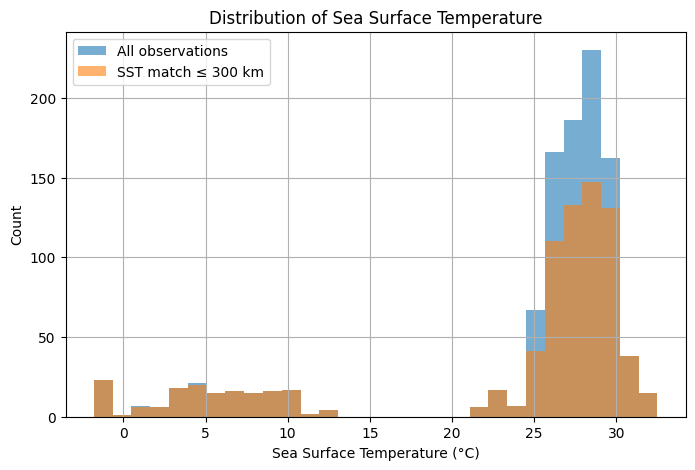

In [24]:
# distribution of SST
plt.figure(figsize=(8,5))

df_model["sst_degC"].hist(
    bins=30,
    alpha=0.6,
    label="All observations"
)

df_model_close["sst_degC"].hist(
    bins=30,
    alpha=0.6,
    label="SST match ≤ 300 km"
)

plt.xlabel("Sea Surface Temperature (°C)")
plt.ylabel("Count")
plt.title("Distribution of Sea Surface Temperature")
plt.legend()

plt.show()